# 📈 Этап 2: Анализ результатов обучения (Training Analysis)

**Цель:** Проанализировать процесс обучения лучшей модели (YOLOv8 Medium на сбалансированных данных), визуализировать графики функций потерь (Loss) и метрик качества (mAP, Precision, Recall). Это соответствует требованиям раздела 3.7 проектного практикума.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("[INFO] Библиотеки загружены.")

[INFO] Библиотеки загружены.


## 1. Загрузка логов обучения
YOLOv8 автоматически логирует каждую эпоху в файл `results.csv`. Мы загрузим его через `pandas`, чтобы построить кастомные графики, доказывающие отсутствие переобучения (overfitting).

In [2]:
results_path = r"C:\Practicum\results\logs\yolov8m_balanced-3\results.csv"

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    print(f"[SUCCESS] Логи загружены! Всего эпох: {len(df)}")
    display(df[['epoch', 'metrics/mAP50(B)', 'metrics/precision(B)', 'metrics/recall(B)']].tail(3))
else:
    print(f"[ERROR] Файл не найден: {results_path}. Проверь название папки в пути!")

[SUCCESS] Логи загружены! Всего эпох: 30


,epoch,metrics/mAP50(B),metrics/precision(B),metrics/recall(B)
27,28,0.86615,0.85868,0.84138
28,29,0.86729,0.86779,0.84160
29,30,0.86427,0.85896,0.84364


## 2. Анализ функций потерь (Loss)
Сравним `train_loss` и `val_loss`. Если `val_loss` начинает расти, пока `train_loss` падает — это признак переобучения.

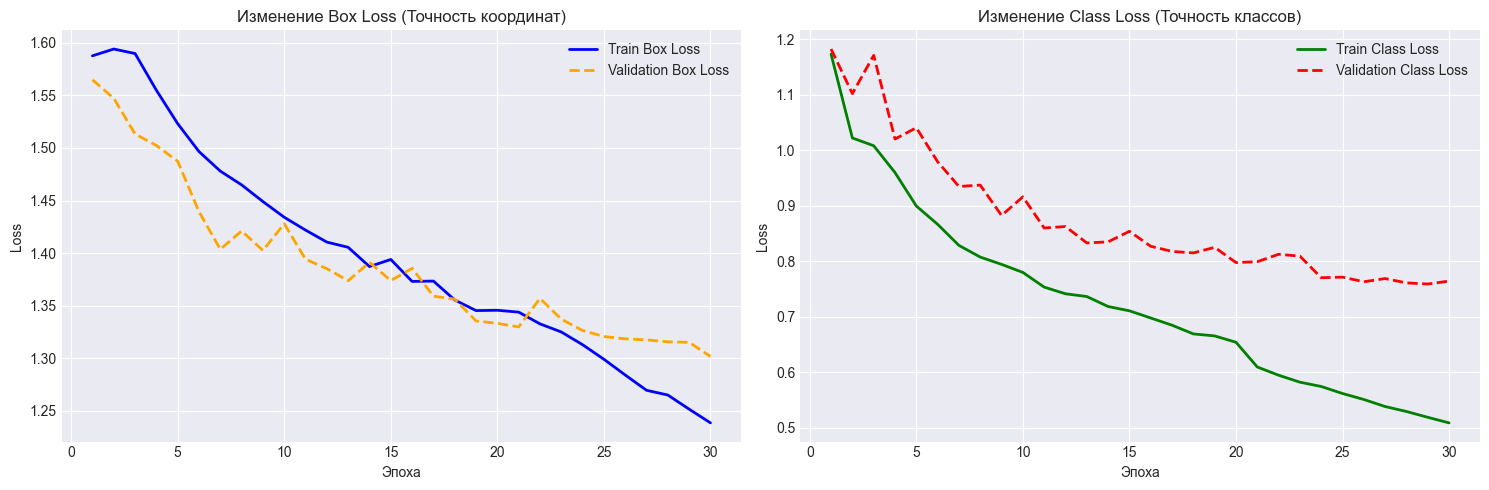

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue', linewidth=2)
axes[0].plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss', color='orange', linewidth=2, linestyle='--')
axes[0].set_title('Изменение Box Loss (Точность координат)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(df['epoch'], df['train/cls_loss'], label='Train Class Loss', color='green', linewidth=2)
axes[1].plot(df['epoch'], df['val/cls_loss'], label='Validation Class Loss', color='red', linewidth=2, linestyle='--')
axes[1].set_title('Изменение Class Loss (Точность классов)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Анализ метрик качества (mAP)
Главная метрика в задачах Object Detection — это **mAP (Mean Average Precision)**. Ожидаемый базовый уровень согласно требованиям: mAP > 0.50.

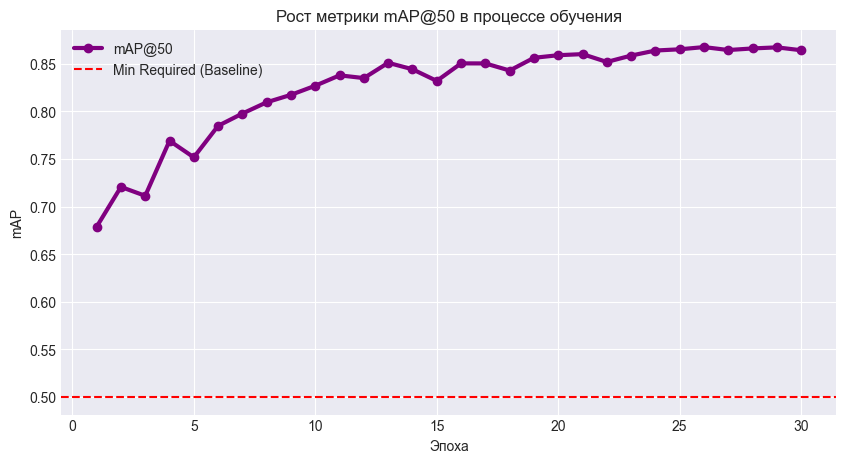

[ВЫВОД] Максимальный достигнутый mAP50: 0.868
[УСПЕХ] Модель значительно превосходит требования Baseline!


In [4]:
plt.figure(figsize=(10, 5))

plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='purple', linewidth=3, marker='o')

plt.axhline(y=0.50, color='r', linestyle='--', label='Min Required (Baseline)')

plt.title('Рост метрики mAP@50 в процессе обучения')
plt.xlabel('Эпоха')
plt.ylabel('mAP')
plt.legend()
plt.grid(True)
plt.show()

max_map = df['metrics/mAP50(B)'].max()
print(f"[ВЫВОД] Максимальный достигнутый mAP50: {max_map:.3f}")
if max_map > 0.5:
    print("[УСПЕХ] Модель значительно превосходит требования Baseline!")